# Proyecto LOST — MountainCarContinuous-v0 (Q-Learning y Dyna-Q)

Notebook de presentación de los resultados. Los experimentos pesados los generan los
scripts (`grid_search.py`, `compare_dyna_q.py`, `episodes_vs_exploration.py`,
`shaping_experiment.py`, `train_best.py`); este notebook **carga los artefactos y los
presenta** para que corra rápido y reproducible.

**Enfoque (según la devolución de la cátedra):** todo se entrena con la **recompensa real**
del ambiente (sin reward shaping). La clave para aprender es la **inicialización optimista**
(Sutton & Barto §2.6), no la recompensa. La experimentación usa **múltiples semillas** y
reporta la **varianza** con boxplots/bandas de error (seaborn).

**Relación con el informe.** Este notebook es el **espejo interactivo** de
`DocumentacionFinal.md` §2 (informe completo). Mapa de secciones:

| Sección del notebook | Sección del informe |
|---|---|
| 1. Discretización | §2.3 |
| 2. Inicialización optimista | §2.1 (problema) + §2.5 |
| 2.1. Más episodios no alcanzan | §2.5.1 |
| 3. Hiperparámetros con varianza | §2.6 + §2.7 |
| 4. Política aprendida | §2.9 |
| 5. Dyna-Q vs Q-Learning | §2.8 |
| 6. Modelos finales | §2.9 |
| 7. Reward shaping (**extra**) | §2.10 |


In [1]:
import json
import pandas as pd
from IPython.display import Image, display

import experiments as ex
from discretization import Discretizer
from q_learning_agent import QLearningAgent
from dyna_q_agent import DynaQAgent

## 1. Discretización

Se discretizan la observación continua `(x, v)` y la acción continua con cortes uniformes
(`np.linspace` + `np.digitize`). El `+1` en el shape cubre el índice extremo de `np.digitize`.

In [2]:
disc = Discretizer(n_bins_x=40, n_bins_v=40, n_actions=5)
print("state_shape:", disc.state_shape, "| q_shape:", disc.q_shape)
print("acciones discretas:", disc.actions)
print("obs (x=0.0, v=0.02) -> índice de estado:", disc.get_state((0.0, 0.02)))

state_shape: (41, 41) | q_shape: (41, 41, 5)
acciones discretas: [-1.  -0.5  0.   0.5  1. ]
obs (x=0.0, v=0.02) -> índice de estado: (27, 26)


## 2. La clave sin tocar la recompensa: inicialización optimista

Sin shaping, la recompensa es escasa y el agente cae en la "trampa de no hacer nada"
(moverse cuesta energía y la meta casi nunca se alcanza). La **inicialización optimista**
(arrancar Q en un valor alto) fuerza a explorar las acciones no probadas. El grid lo mide:
con `opt=0/1` el agente fracasa (0 %); con `opt≥10` resuelve el ambiente.

In [3]:
grid = pd.DataFrame(json.load(open("grid_search_results.json")))
opt = grid[grid["config"].str.startswith(("opt", "base"))]
print("Éxito en test (mediana sobre seeds) según inicialización optimista:")
print(opt.groupby("config")["test_success"].median().to_string())

Éxito en test (mediana sobre seeds) según inicialización optimista:
config
base (bins40, opt=10)    1.0
opt=0 (trampa)           0.0
opt=1                    0.0
opt=50                   1.0


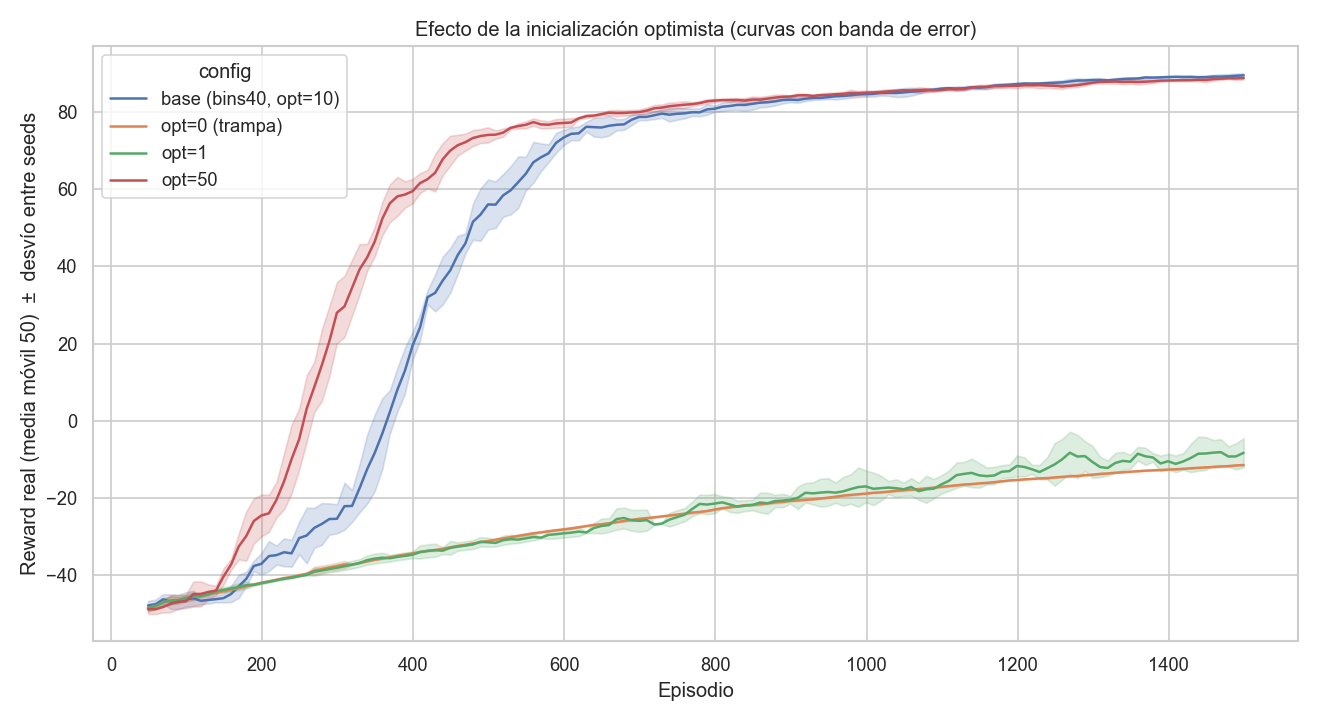

In [4]:
display(Image("plots/grid_search_optinit_curves.png"))   # curvas con banda de error

### 2.1. ¿Y si entreno muchos más episodios? (no alcanza) — informe §2.5.1

La cátedra observó que *"1500 episodios es muy poco y deberían poder con Q-Learning"*. Lo
verificamos: el cuello de botella **no es la cantidad de episodios sino la exploración**.
Comparamos Q-Learning **vanilla** (`opt=0`) vs **inicialización optimista** (`opt=10`) a
1.500 / 5.000 / 10.000 episodios. El vanilla sigue en **0 %** aun con 10.000 episodios
(llega a la meta apenas **0–2 veces en todo el entrenamiento**, así que no tiene de dónde
aprender); el optimista resuelve. **Más episodios sin exploración no mueven la aguja.**

In [5]:
ev = pd.DataFrame(json.load(open("episodes_vs_exploration.json")))
print("Éxito en test y metas alcanzadas DURANTE el entrenamiento (media sobre seeds):")
print(ev.groupby(["variante", "episodios"])[["test_success", "metas_train"]].mean().round(2).to_string())

Éxito en test y metas alcanzadas DURANTE el entrenamiento (media sobre seeds):
                                                test_success  metas_train
variante                             episodios                           
Q-Learning + init optimista (opt=10) 1500               0.93      1131.33
                                     5000               1.00      4631.33
                                     10000              1.00      9631.33
Q-Learning vanilla (opt=0)           1500               0.00         0.67
                                     5000               0.00         0.67
                                     10000              0.00         0.67


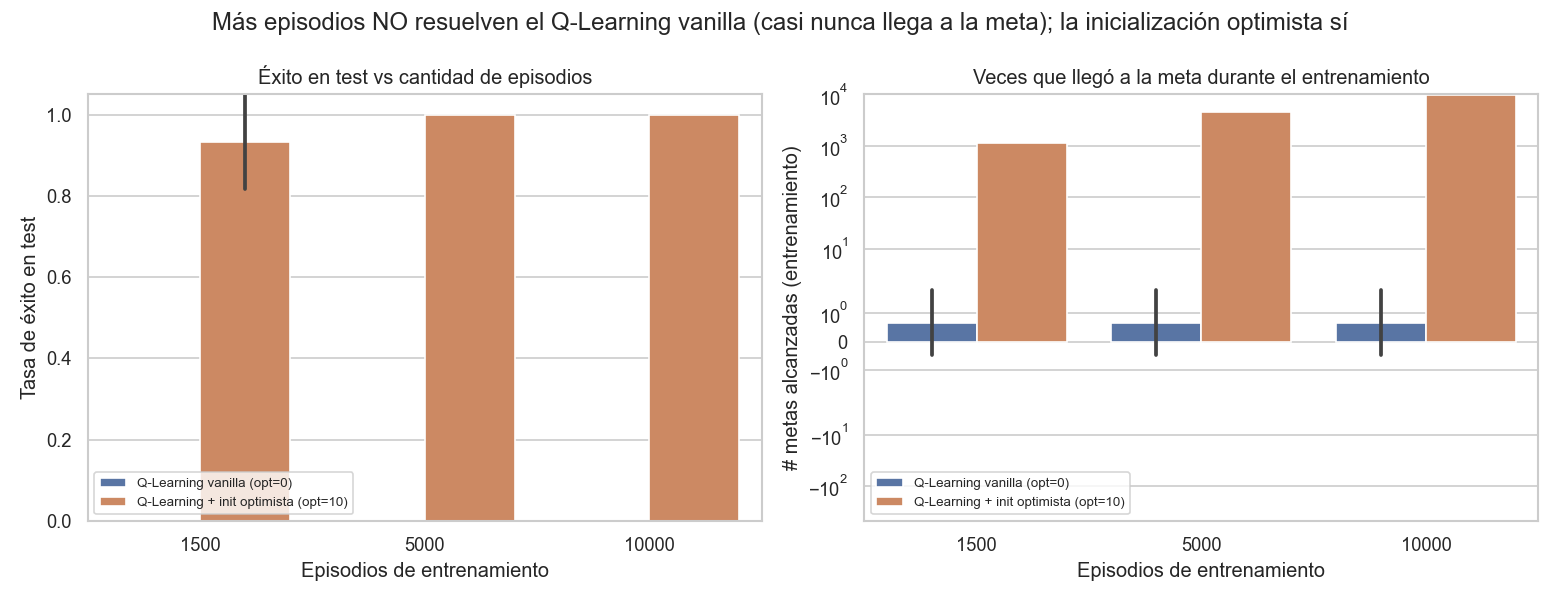

In [6]:
display(Image("plots/episodes_vs_exploration.png"))   # vanilla vs optimista a más episodios

## 3. Exploración de hiperparámetros con análisis de varianza

Grid one-at-a-time (α, γ, ε-decay, discretización, inicialización optimista), cada config
con **5 semillas**. Se reporta mediana y varianza. La **selección es robusta**: prioriza
que TODAS las seeds resuelvan (`test_success_min`) y baja varianza, no la mediana sola.

In [7]:
summ = ex.summary(grid).sort_values(
    ["test_success_min", "test_reward_std", "test_steps_mediana"], ascending=[False, True, True])
summ

,config,n_seeds,test_success_mediana,test_success_min,test_reward_mediana,test_reward_std,test_steps_mediana,conv_ep_mediana
1,alpha=0.3,5,1.0,1.0,91.560000,0.56,157.1,1117.0
10,opt=50,5,1.0,1.0,90.925000,1.08,188.4,381.0
0,alpha=0.05,5,1.0,1.0,90.670000,1.93,265.3,727.0
4,bins60 (fina),5,1.0,0.9,79.647777,5.39,481.4,1070.0
7,gamma=0.999,5,1.0,0.8,91.255000,8.29,371.5,1500.0
2,"base (bins40, opt=10)",5,1.0,0.8,92.212500,11.31,190.1,520.0
5,decay=0.995,5,1.0,0.8,91.637500,14.10,191.3,318.0
6,gamma=0.95,5,1.0,0.5,88.595000,27.83,249.8,411.0
8,opt=0 (trampa),5,0.0,0.0,0.000000,0.00,999.0,1500.0
9,opt=1,5,0.0,0.0,0.000000,0.00,999.0,1500.0


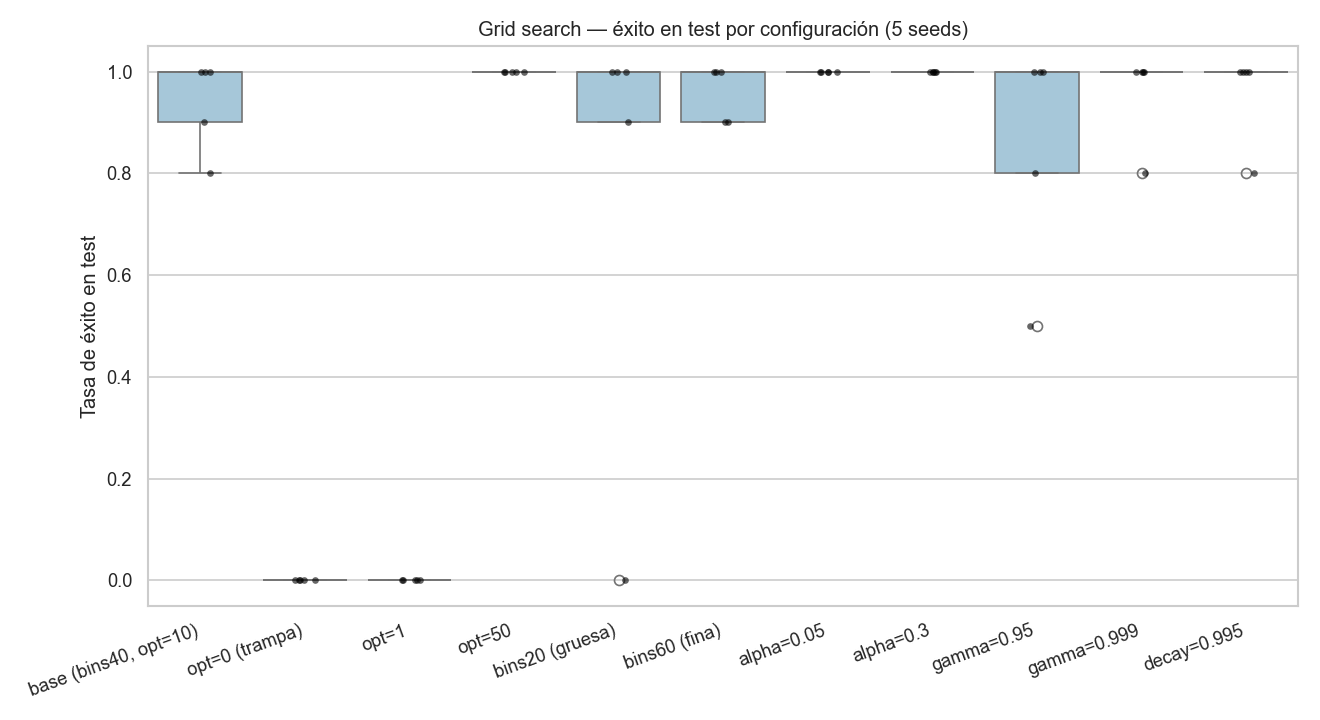

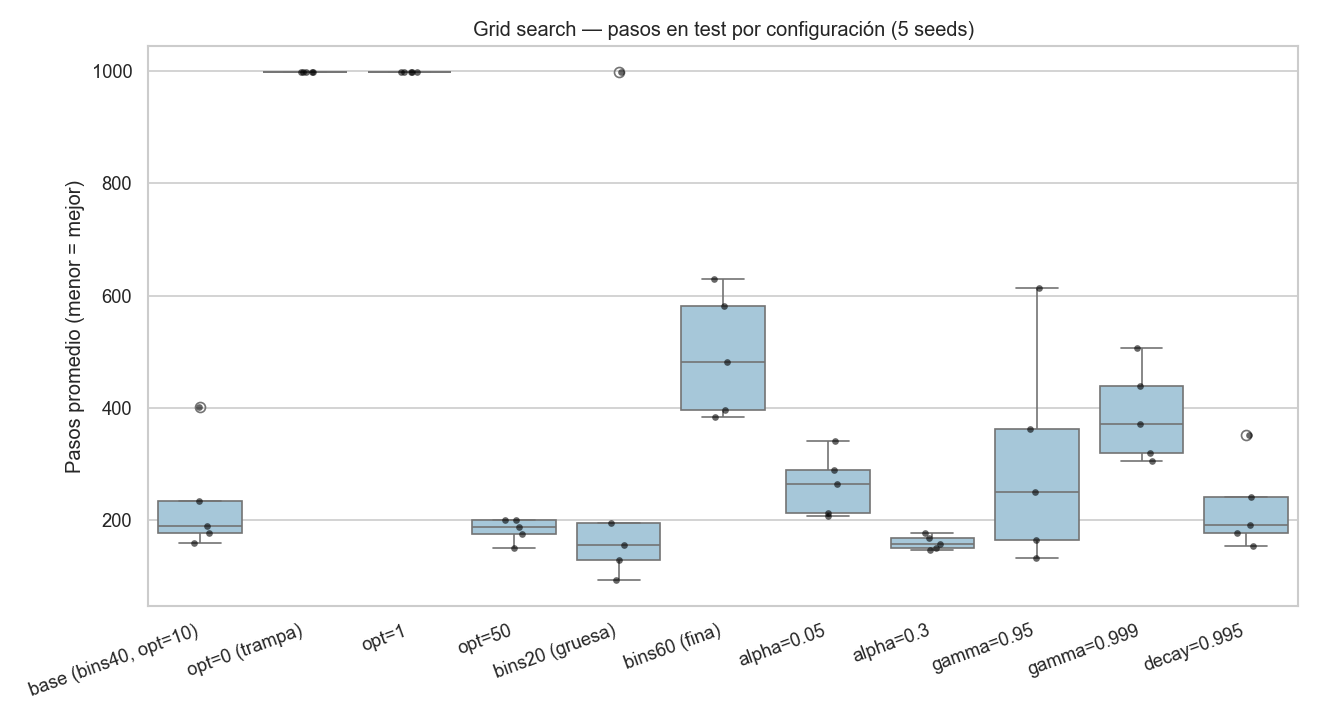

In [8]:
# Boxplots: la varianza distingue las configs robustas de las "buenas de casualidad".
display(Image("plots/grid_search_box_success.png"))
display(Image("plots/grid_search_box_steps.png"))

**Lectura:** `bins20 (gruesa)` tiene buena mediana de pasos pero **una seed da 0 %** →
inestable. La elección robusta es **`α=0.3`** (resuelve en las 5 seeds, baja varianza).
Mirar la varianza evita elegir una config que "gana de casualidad".

## 4. Visualización de la política aprendida

Mapa de `π(s)` en el espacio `(x, v)` del mejor modelo: patrón clásico **"pump-and-go"**
(empujar hacia atrás cuando `v<0`, hacia adelante cuando `v>0`). Celdas no visitadas
enmascaradas.

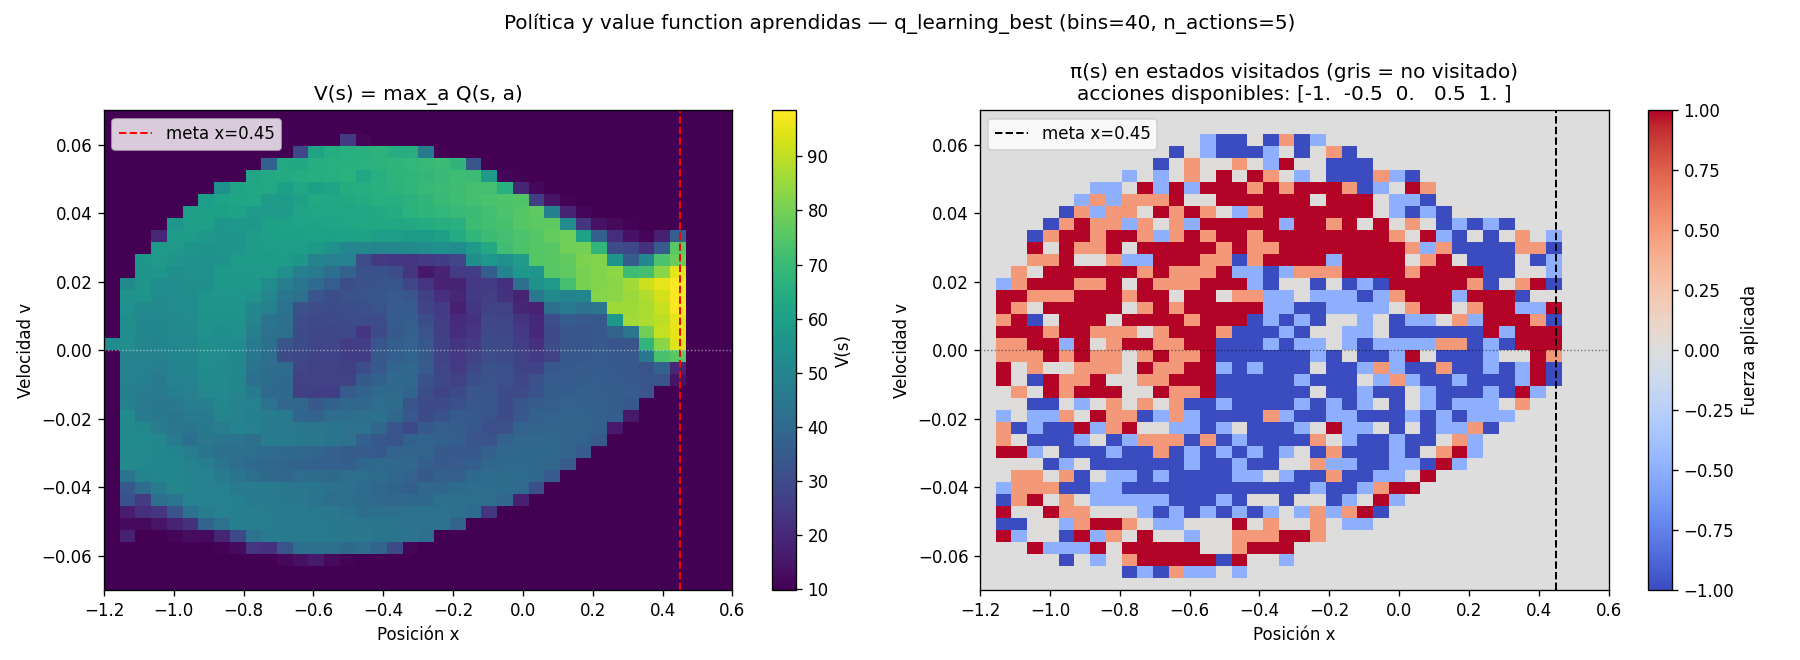

q_learning_best.pkl -> α: 0.3 | opt_init: 10.0 | reward_shaping: False


In [9]:
display(Image("plots/q_learning_best_policy.png"))
ql = QLearningAgent.load("models/q_learning_best.pkl")
print("q_learning_best.pkl -> α:", ql.alpha, "| opt_init:", ql.optimistic_init,
      "| reward_shaping:", ql.reward_shaping)

## 5. Dyna-Q vs Q-Learning (componente de investigación)

Dyna-Q (S&B §8.2) = Q-Learning + modelo del ambiente + `n` pasos de planning. Comparación
`n ∈ {0, 5, 25}` con la **recompensa real**, 5 seeds, apareado.

In [10]:
dq = pd.DataFrame(json.load(open("dyna_q_comparison.json")))
ex.summary(dq)

,config,n_seeds,test_success_mediana,test_success_min,test_reward_mediana,test_reward_std,test_steps_mediana,conv_ep_mediana
0,Dyna-Q (n=25),5,1.0,0.1,84.90,66.90,238.2,544.0
1,Dyna-Q (n=5),5,1.0,1.0,93.15,1.53,104.9,349.0
2,Q-Learning (n=0),5,1.0,1.0,92.45,0.94,203.4,520.0


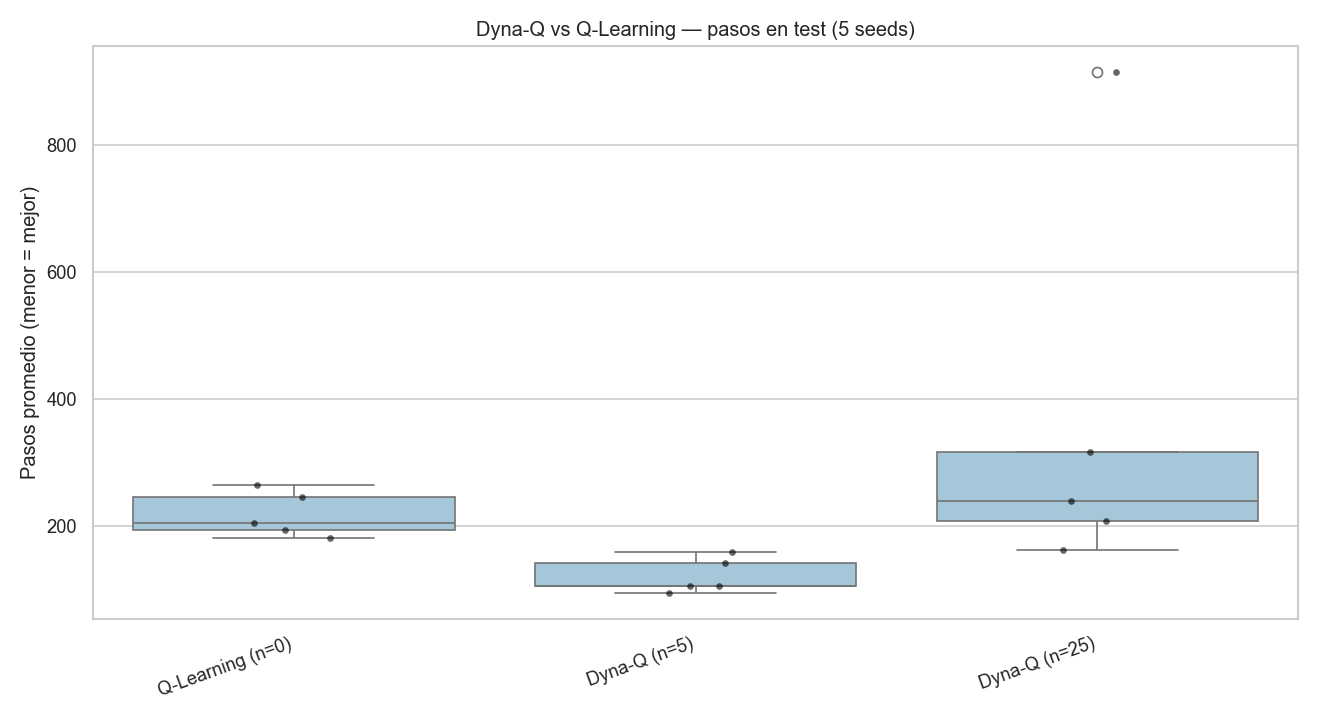

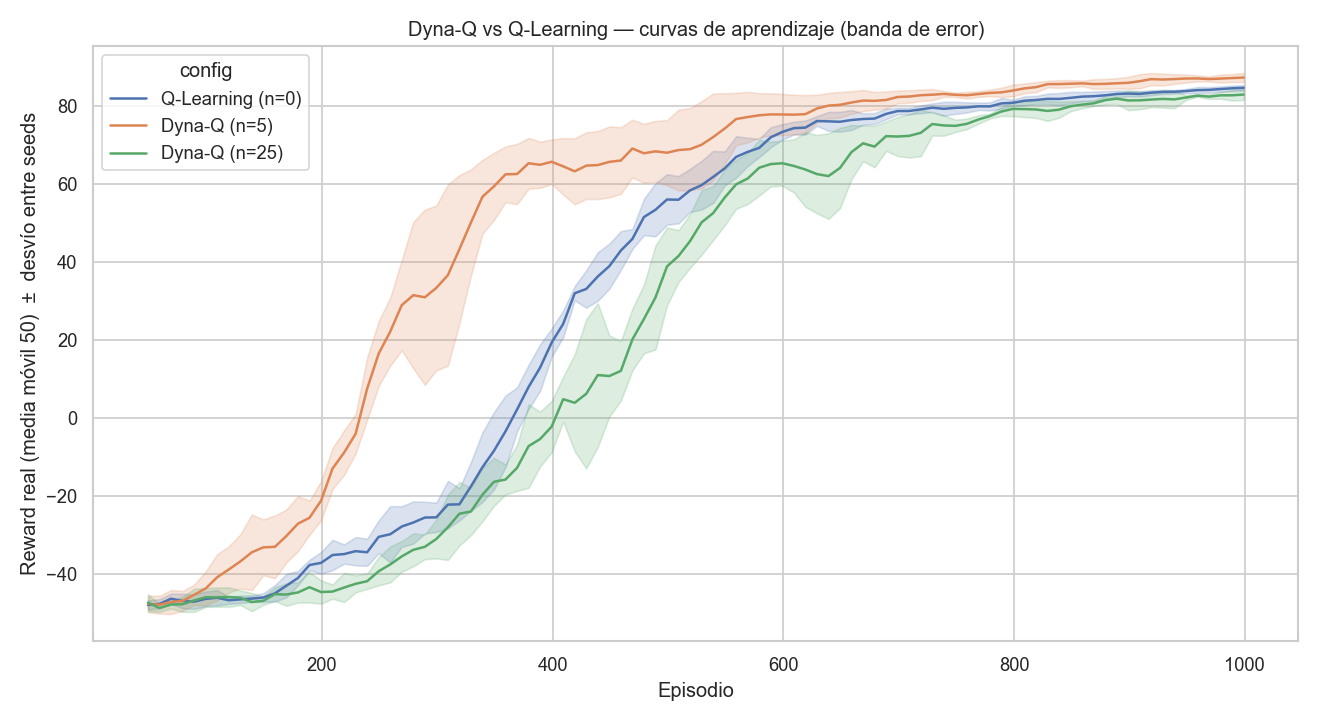

In [11]:
display(Image("plots/dyna_q_box_steps.png"))
display(Image("plots/dyna_q_curves.png"))

**Conclusión (matizada):** planning **moderado (n=5)** converge antes y da mejor política
(~105 vs ~203 pasos), al costo de ~3× más cómputo; **demasiado planning (n=25)** se vuelve
**inestable** (alta varianza, alguna seed casi falla). No es "Dyna-Q siempre mejor", sino
"depende de cuánto planning".

## 6. Modelos finales entregables (recompensa real, sin shaping)

In [12]:
import gymnasium as gym
ql = QLearningAgent.load("models/q_learning_best.pkl")
dq_best = DynaQAgent.load("models/dyna_q_best.pkl")
env = gym.make("MountainCarContinuous-v0")
for name, ag in [("q_learning_best (α=0.3, n=0)", ql), ("dyna_q_best (n=5)", dq_best)]:
    m = ag.test_agent(env, episodes=20, test_seeds=ex.TEST_SEEDS)
    print(f"{name:30s} -> éxito={m['success_rate']:.0%}  reward={m['avg_reward']:.1f}  pasos={m['avg_steps']:.1f}")
env.close()

q_learning_best (α=0.3, n=0)   -> éxito=100%  reward=91.6  pasos=140.8
dyna_q_best (n=5)              -> éxito=100%  reward=94.2  pasos=83.3


## 7. Reward shaping (extra, no parte del núcleo) — informe §2.10

El reward shaping **modifica la recompensa** (= cambia el ambiente), por eso la cátedra lo
admite **solo como extra**: todo lo anterior usa la **recompensa real**. Aun así lo medimos
de forma honesta (potential-based, Ng-Harada-Russell 1999, `Φ(s)=coef·|v|`), con **4
variantes × 5 seeds**, preguntando: ¿el shaping **rescata** al vanilla (`opt=0`)? ¿**acelera**
al optimista (`opt=10`)?

In [13]:
shap = pd.DataFrame(json.load(open("shaping_comparison.json")))
ex.summary(shap).sort_values("conv_ep_mediana")

,config,n_seeds,test_success_mediana,test_success_min,test_reward_mediana,test_reward_std,test_steps_mediana,conv_ep_mediana
1,optimista+shaping (opt=10),5,1.0,1.0,93.0925,1.85,146.3,222.0
2,shaping (opt=0),5,1.0,0.9,94.2200,4.92,169.5,246.0
0,optimista (opt=10),5,1.0,0.8,92.2125,11.31,190.1,520.0
3,vanilla (opt=0),5,0.0,0.0,0.0000,0.00,999.0,1500.0


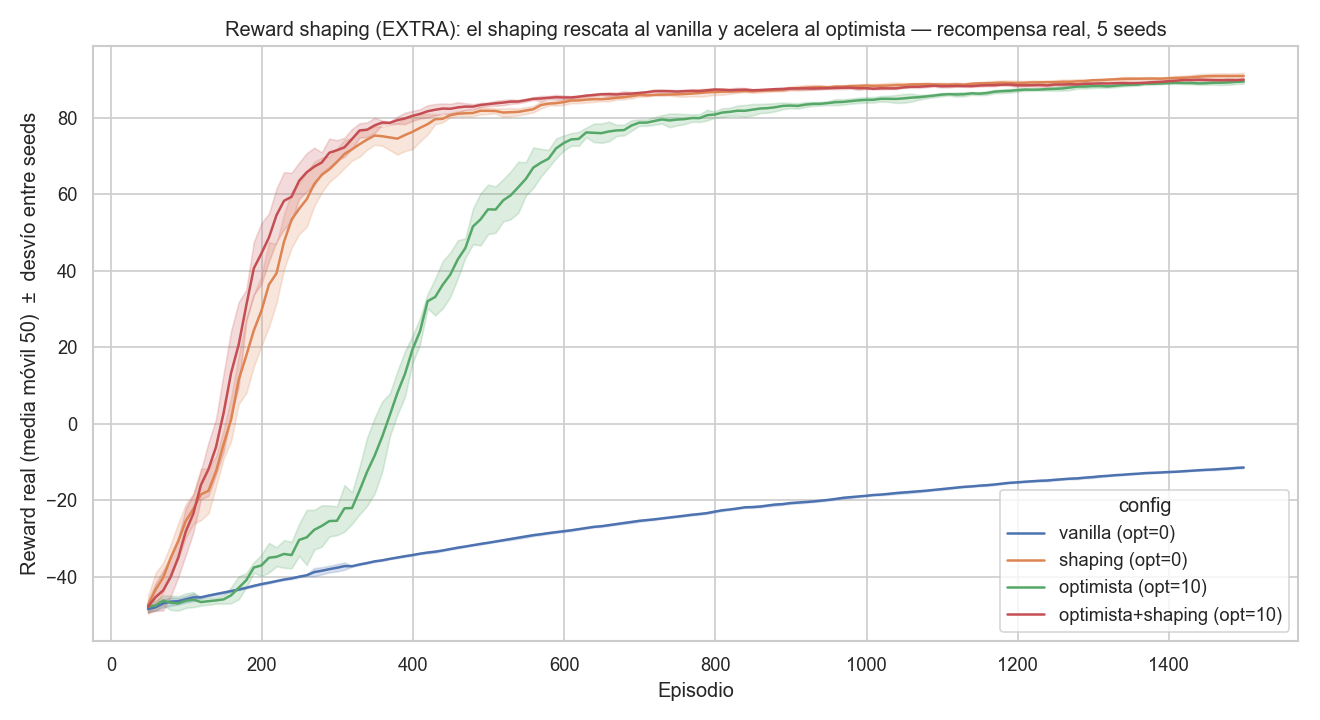

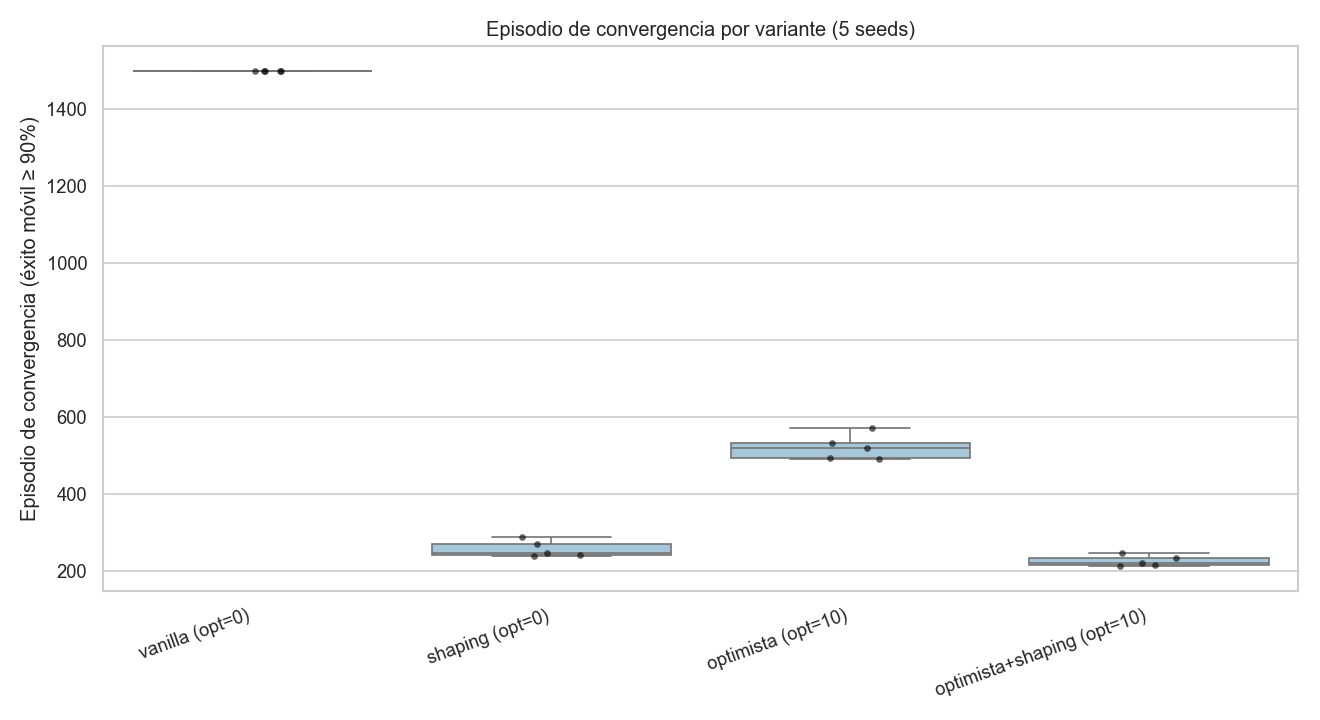

In [14]:
display(Image("plots/shaping_curves.png"))     # curvas con banda de error (recompensa real)
display(Image("plots/shaping_box_conv.png"))   # episodio de convergencia por variante

**Lectura.** El shaping **rescata al vanilla** (`opt=0`: 0 %→100 %, converge ~246 ep) y
**acelera al optimista** (`opt=10`: 520→222 ep, más estable y mejor política). Funciona muy
bien, pero **modifica la recompensa**: nuestro núcleo ya resuelve **sin tocar el ambiente**
(inicialización optimista), así que el shaping queda como un **atajo válido pero no
necesario** — exactamente el lugar que le da la cátedra.